<span style="color:red; font-family:Helvetica Neue, Helvetica, Arial, sans-serif; font-size:2em;">An Exception was encountered at '<a href="#papermill-error-cell">In [25]</a>'.</span>

In [1]:
import sys
from pathlib import Path

root_dir = Path().absolute()
# Strip ~/notebooks/ccfraud from PYTHON_PATH if notebook started in one of these subdirectories
if root_dir.parts[-1:] == ('notebooks',):
    root_dir = Path(*root_dir.parts[:-1])
    sys.path.append(str(root_dir))
if root_dir.parts[-1:] == ('ccfraud',):
    root_dir = Path(*root_dir.parts[:-1])
    sys.path.append(str(root_dir))
root_dir = str(root_dir) 

print(f"Root dir: {root_dir}")

# Set the environment variables from the file <root_dir>/.env
from mlfs import config
settings = config.HopsworksSettings(_env_file=f"{root_dir}/.env")

Root dir: /Users/igormedeiros/Workspaces/irgmedeiros/mlfs-book
HopsworksSettings initialized!


In [2]:
import hopsworks
import pandas as pd
import shutil

proj = hopsworks.login()
fs = proj.get_feature_store()
mr = proj.get_model_registry()

env_api = proj.get_environment_api()
ds_api = proj.get_dataset_api()

2026-07-08 10:12:48,211 INFO: Initializing external client


2026-07-08 10:12:48,211 INFO: Base URL: https://eu-west.cloud.hopsworks.ai:443


2026-07-08 10:12:49,713 INFO: Python Engine initialized.



Logged in to project, explore it here https://eu-west.cloud.hopsworks.ai:443/p/36986


In [3]:
merchant_fg = fs.get_feature_group("merchant_details", version=1)
account_fg = fs.get_feature_group("account_details", version=1)
bank_fg = fs.get_feature_group("bank_details", version=1)
card_fg = fs.get_feature_group("card_details", version=1)
cc_trans_aggs_fg = fs.get_feature_group("cc_trans_aggs_fg", version=1)
cc_trans_fg = fs.get_feature_group("cc_trans_fg", version=1)

In [4]:
subtree1 = cc_trans_aggs_fg.select_except(['t_id','cc_num','account_id','bank_id','event_time'])\
    .join(account_fg.select(['debt_end_prev_month']), on="account_id")\
    .join(bank_fg.select(['credit_rating', 'days_since_bank_cr_changed', 'country']), prefix="bank_", on="bank_id")

In [5]:
# df = subtree1.read()
# df.isna().sum().sort_values(ascending=False)
# df

In [6]:
selection = cc_trans_fg.select_except(['t_id', 'cc_num', 'merchant_id', 'account_id', 'ip_address', 'ts'])\
    .join(merchant_fg.select_features(), on="merchant_id", join_type="inner")\
    .join(subtree1, on="cc_num")
# , prefix="aggs_"
# , prefix="merchant_"

2026-07-08 10:12:55,769 INFO: Using ['category', 'country', 'cnt_chrgeback_prev_day', 'cnt_chrgeback_prev_week', 'cnt_chrgeback_prev_month'] from feature group `merchant_details` as features for the query. To include primary key and event time use `select_all`.


In [7]:
# df = selection.read()
# df.isna().sum().sort_values(ascending=False)

In [8]:
fv = fs.get_or_create_feature_view(name="cc_fraud_fv", 
                                   version=1, 
                                   description="features for a credit card fraud prediction model",
                                   query=selection,
                                   labels=['is_fraud'],
                                   inference_helper_columns=['prev_card_present','prev_ip_address','prev_ts']
                                  )

Feature view created successfully, explore it at 
https://eu-west.cloud.hopsworks.ai:443/p/36986/fs/26695/fv/cc_fraud_fv/version/1


In [9]:
# Parameters
test_start = "2026-07-01 00:00"


In [10]:
import time

read_options = {"arrow_flight_config": {"timeout": 900}}
X_train = X_test = y_train = y_test = None

for attempt in range(1, 4):
    try:
        X_train, X_test, y_train, y_test = fv.train_test_split(
            test_start=test_start,
            read_options=read_options,
        )
        print(f"Offline train_test_split succeeded on attempt {attempt}")
        break
    except Exception as exc:
        print(f"train_test_split attempt {attempt}/3 failed: {type(exc).__name__}: {exc}")
        if attempt < 3:
            time.sleep(30)

if X_train is None:
    print("Falling back to materialized train_test_split via Spark job...")
    td_version, td_job = fv.create_train_test_split(
        test_start=test_start,
        data_format="parquet",
        write_options={"use_spark": True},
    )
    td_job.wait_for_completion(timeout=900)
    X_train, X_test, y_train, y_test = fv.get_train_test_split(
        training_dataset_version=td_version,
        read_options=read_options,
    )
    print(f"Materialized split succeeded (training dataset v{td_version})")

print(f"Train rows: {len(X_train):,}; test rows: {len(X_test):,}")
print(f"Fraud labels in train: {int(y_train['is_fraud'].sum())}; in test: {int(y_test['is_fraud'].sum())}")
X_train


2026-07-08 10:13:26,397 INFO: Computing insert statistics


2026-07-08 10:13:26,432 INFO: Computing insert statistics


Finished: Reading data from Hopsworks, using Hopsworks Feature Query Service (4.48s) 


2026-07-08 10:13:27,314 WARNING: VersionWarning: Incremented version to `1`.



Offline train_test_split succeeded on attempt 1
Train rows: 36,067; test rows: 11,961
Fraud labels in train: 132; in test: 71


,amount,time_since_last_trans,days_to_card_expiry,haversine_distance,category,country,cnt_chrgeback_prev_day,cnt_chrgeback_prev_week,cnt_chrgeback_prev_month,num_trans_last_10_mins,...,num_trans_last_hour,sum_trans_last_hour,num_trans_last_day,sum_trans_last_day,num_trans_last_week,sum_trans_last_week,debt_end_prev_month,bank_credit_rating,bank_days_since_bank_cr_changed,bank_country
0,7.40,-2573788,0,True,Entertainment,France,0.38,2.34,13.21,1,...,1,7.40,1,7.40,1,7.40,2865.01,8.0,218.0,Russia
1,8.12,-2525942,0,True,Pharmacy,Turkey,2.37,18.40,79.84,1,...,1,8.12,1,8.12,1,8.12,1443.48,8.0,218.0,Russia
2,17.76,-2463163,0,True,Department Stores,Canada,2.24,14.79,53.95,1,...,1,17.76,1,17.76,1,17.76,2646.51,8.0,218.0,Russia
3,20.35,-2198838,0,True,Beauty,Mexico,8.43,54.55,297.70,1,...,1,20.35,1,20.35,1,20.35,960.23,8.0,218.0,Russia
4,12.13,-2524680,0,True,Electronics,China,2.30,13.17,61.51,1,...,1,12.13,1,12.13,1,12.13,5978.99,8.0,218.0,Russia
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
47827,6.80,155734,0,True,Furniture,France,0.33,1.96,11.73,1,...,1,6.80,1,6.80,5,173.76,2367.58,9.0,374.0,Italy
47828,13.56,200147,0,True,Fashion,Australia,0.60,3.96,20.22,1,...,1,13.56,1,13.56,3,125.25,2589.45,9.0,374.0,Italy
47829,599.31,97217,0,True,Beauty,Mexico,8.43,54.55,297.70,1,...,1,599.31,1,599.31,3,636.01,2536.77,9.0,374.0,Italy
47830,5.07,61527,0,True,Beauty,Mexico,8.43,54.55,297.70,1,...,1,5.07,3,605.58,10,1150.37,-952.88,9.0,374.0,Italy


In [11]:
X_test

,amount,time_since_last_trans,days_to_card_expiry,haversine_distance,category,country,cnt_chrgeback_prev_day,cnt_chrgeback_prev_week,cnt_chrgeback_prev_month,num_trans_last_10_mins,...,num_trans_last_hour,sum_trans_last_hour,num_trans_last_day,sum_trans_last_day,num_trans_last_week,sum_trans_last_week,debt_end_prev_month,bank_credit_rating,bank_days_since_bank_cr_changed,bank_country
739,35.38,27989,0,False,Pet Supplies,Mexico,0.05,0.33,1.37,1,...,1,35.38,2,156.54,9,705.33,2577.92,8.0,218.0,Russia
740,9.96,30674,0,True,Furniture,France,0.33,1.96,11.73,1,...,1,9.96,3,52.85,7,797.18,2865.01,8.0,218.0,Russia
741,22.97,49966,0,True,Jewelry,Canada,0.91,5.46,30.62,1,...,1,22.97,2,50.86,5,178.83,2794.78,8.0,218.0,Russia
742,32.96,17074,0,True,Department Stores,Canada,2.24,14.79,53.95,1,...,1,32.96,4,120.84,10,680.67,3976.48,8.0,218.0,Russia
743,110.75,10530,0,False,Fashion,Thailand,6.00,43.03,165.66,1,...,1,110.75,3,239.16,6,663.14,1287.55,8.0,218.0,Russia
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48023,82.70,102322,0,True,Home Improvement,Japan,1.14,8.99,28.87,1,...,1,82.70,1,82.70,7,265.43,1703.50,9.0,374.0,Italy
48024,47.51,158066,0,True,Travel,China,1.52,11.52,40.64,1,...,1,47.51,1,47.51,5,838.06,4047.77,9.0,374.0,Italy
48025,147.40,223472,0,True,Jewelry,Canada,0.91,5.46,30.62,1,...,1,147.40,1,147.40,8,433.60,2126.45,9.0,374.0,Italy
48026,132.04,10382,0,False,Beauty,Mexico,8.43,54.55,297.70,1,...,1,132.04,1,132.04,6,369.90,2126.45,9.0,374.0,Italy


In [12]:
y_train.value_counts()

is_fraud
False       35935
True          132
Name: count, dtype: int64

In [13]:
# Data is ready for training
# The unified Pipeline will handle preprocessing internally
# No need to transform data separately - just pass raw X_train/X_test to the pipeline

print(f"Training data: {X_train.shape[0]:,} samples, {X_train.shape[1]} features")
print(f"Test data: {X_test.shape[0]:,} samples, {X_test.shape[1]} features")
print("\nRaw features will be preprocessed by the unified Pipeline during fit/predict.")

Training data: 36,067 samples, 21 features
Test data: 11,961 samples, 21 features

Raw features will be preprocessed by the unified Pipeline during fit/predict.


In [14]:
# Define Preprocessing Components for Pipeline
# These will be combined with the model into a unified sklearn Pipeline

from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder
from sklearn.pipeline import Pipeline
import numpy as np

print("DEFINING PREPROCESSING COMPONENTS")
print("Missing values in training data:")
print(X_train.isnull().sum()[X_train.isnull().sum() > 0])

# Identify numeric and categorical columns
categorical_features = ['category', 'country', 'bank_country']
numeric_features = [col for col in X_train.columns if col not in categorical_features]

print(f"\nNumeric features ({len(numeric_features)}): {numeric_features[:5]}...")
print(f"Categorical features ({len(categorical_features)}): {categorical_features}")

# Create preprocessing pipeline with both imputation and encoding
# Numeric pipeline: just impute missing values
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median'))
])

# Categorical pipeline: impute missing values then encode
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='UNKNOWN')),
    ('encoder', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1))
])

# Combine into a single ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ],
    verbose_feature_names_out=False
)

print("\nPreprocessing components defined (will be fitted as part of unified Pipeline)")
print("  - Numeric: median imputation")
print("  - Categorical: constant imputation ('UNKNOWN') + ordinal encoding")

DEFINING PREPROCESSING COMPONENTS
Missing values in training data:
debt_end_prev_month                1465
bank_credit_rating                 1811
bank_days_since_bank_cr_changed    1811
bank_country                       1811
dtype: int64

Numeric features (18): ['amount', 'time_since_last_trans', 'days_to_card_expiry', 'haversine_distance', 'cnt_chrgeback_prev_day']...
Categorical features (3): ['category', 'country', 'bank_country']

Preprocessing components defined (will be fitted as part of unified Pipeline)
  - Numeric: median imputation
  - Categorical: constant imputation ('UNKNOWN') + ordinal encoding


In [15]:
# Preview Preprocessing Pipeline Structure
# This shows what the preprocessing will do when fitted as part of the unified Pipeline

print("=" * 80)
print("PREPROCESSING PIPELINE STRUCTURE")
print("=" * 80)

print("\nPreprocessing Pipeline Structure:")
print(preprocessor)

print("\nPreprocessing steps:")
print("  1. Numeric features: Impute missing values with median")
print("  2. Categorical features: Impute missing with 'UNKNOWN', then ordinal encode")
print("\nThis preprocessor will be combined with XGBoost into a single Pipeline")
print("and fitted together in the next step.")

PREPROCESSING PIPELINE STRUCTURE

Preprocessing Pipeline Structure:
ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median'))]),
                                 ['amount', 'time_since_last_trans',
                                  'days_to_card_expiry', 'haversine_distance',
                                  'cnt_chrgeback_prev_day',
                                  'cnt_chrgeback_prev_week',
                                  'cnt_chrgeback_prev_month',
                                  'num_trans_last_10_mins',
                                  'sum_trans_last_10_mins',
                                  'num_trans_last_hour', 'sum_trans_last_hour'...
                                  'num_trans_last_week', 'sum_trans_last_week',
                                  'debt_end_prev_month', 'bank_credit_rating',
                                  'bank_days_since_b

In [16]:
# Calculate scale_pos_weight
# This is the key parameter for handling class imbalance in XGBoost

n_negative = (y_train["is_fraud"] == False).sum()
n_positive = (y_train["is_fraud"] == True).sum()
scale_pos_weight = n_negative / n_positive if n_positive > 0 else 1.0

print("=" * 80)
print("CLASS IMBALANCE ANALYSIS")
print("=" * 80)
print(f"Negative samples (non-fraud): {n_negative:,}")
print(f"Positive samples (fraud):     {n_positive:,}")
print(f"Imbalance ratio:              {scale_pos_weight:.2f}:1")
print(f"\nscale_pos_weight parameter:   {scale_pos_weight:.2f}")
print("\nThis parameter tells XGBoost to give ~{:.0f}x more weight to fraud cases".format(scale_pos_weight))
print("during training to compensate for the severe class imbalance.")

CLASS IMBALANCE ANALYSIS
Negative samples (non-fraud): 35,935
Positive samples (fraud):     132
Imbalance ratio:              272.23:1

scale_pos_weight parameter:   272.23

This parameter tells XGBoost to give ~272x more weight to fraud cases
during training to compensate for the severe class imbalance.


In [17]:
# Train Unified sklearn Pipeline (Preprocessor + XGBoost)
# Single Pipeline for preprocessing and prediction

import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')

print("=" * 80)
print("TRAINING UNIFIED SKLEARN PIPELINE")
print("=" * 80)

# Create unified Pipeline combining preprocessing and model
# Note: Early stopping is removed because sklearn Pipeline doesn't support eval_set
# We use a fixed n_estimators instead (100 is a good default)
full_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', xgb.XGBClassifier(
        scale_pos_weight=scale_pos_weight,  # Handle class imbalance
        max_depth=6,                        # Control overfitting
        learning_rate=0.1,                  # Standard learning rate
        n_estimators=100,                   # Fixed number of boosting rounds
        eval_metric='aucpr',                # PR-AUC: best metric for imbalanced data
        random_state=42,                    # Reproducibility
        use_label_encoder=False,            # Avoid deprecation warning
        enable_categorical=False            # We pre-encoded categoricals
    ))
])

print("Pipeline configuration:")
print(f"  Preprocessor: ColumnTransformer (imputation + encoding)")
print(f"  Model: XGBClassifier")
print(f"    - scale_pos_weight: {scale_pos_weight:.2f}")
print(f"    - max_depth:        6")
print(f"    - learning_rate:    0.1")
print(f"    - n_estimators:     100 (fixed, no early stopping)")
print(f"    - eval_metric:      aucpr")

print("\nTraining unified pipeline on RAW data...")

# Train the entire pipeline on RAW (untransformed) data
# The pipeline handles preprocessing internally
full_pipeline.fit(X_train, y_train.values.ravel())

print("\nTraining complete!")
print("Pipeline steps: preprocessor -> model")
print("Ready for inference with raw feature data.")

TRAINING UNIFIED SKLEARN PIPELINE
Pipeline configuration:
  Preprocessor: ColumnTransformer (imputation + encoding)
  Model: XGBClassifier
    - scale_pos_weight: 272.23
    - max_depth:        6
    - learning_rate:    0.1
    - n_estimators:     100 (fixed, no early stopping)
    - eval_metric:      aucpr

Training unified pipeline on RAW data...



Training complete!
Pipeline steps: preprocessor -> model
Ready for inference with raw feature data.


TOP 15 MOST IMPORTANT FEATURES
                        feature  importance
          time_since_last_trans    0.422953
                         amount    0.156489
         cnt_chrgeback_prev_day    0.052559
             num_trans_last_day    0.040831
            sum_trans_last_week    0.031713
             sum_trans_last_day    0.027582
            num_trans_last_hour    0.026764
                        country    0.025496
            num_trans_last_week    0.024897
             haversine_distance    0.023500
            debt_end_prev_month    0.021371
       cnt_chrgeback_prev_month    0.020011
bank_days_since_bank_cr_changed    0.019494
         sum_trans_last_10_mins    0.019012
            sum_trans_last_hour    0.017972


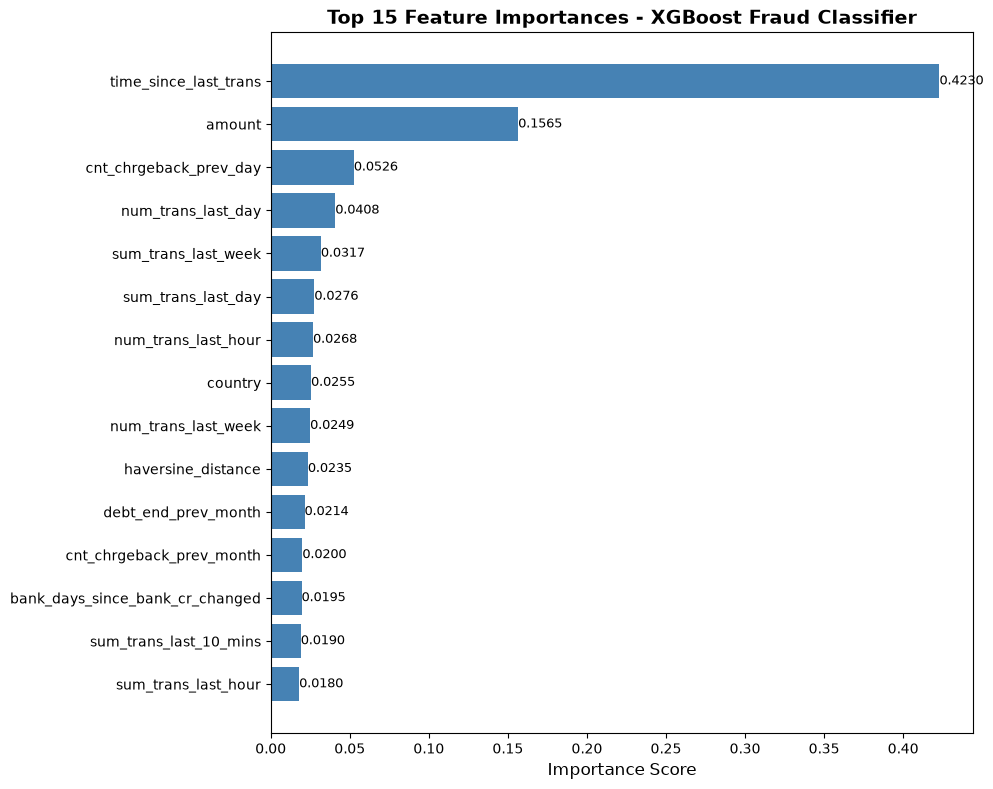


Interpretation:
Features with higher importance scores have more influence on fraud predictions.
Geographic indicators, transaction patterns, and merchant history are key fraud signals.


In [18]:
# Feature Importance
# Analyze which features are most important for fraud detection
import matplotlib.pyplot as plt

# Access model and preprocessor from the pipeline
xgb_model = full_pipeline.named_steps['model']
fitted_preprocessor = full_pipeline.named_steps['preprocessor']

# Get feature names after preprocessing transformation
feature_names = fitted_preprocessor.get_feature_names_out()

# Get feature importance from the model
feature_importance = pd.DataFrame({
    'feature': feature_names,
    'importance': xgb_model.feature_importances_
}).sort_values('importance', ascending=False)

# Display top 15 features
print("=" * 80)
print("TOP 15 MOST IMPORTANT FEATURES")
print("=" * 80)
print(feature_importance.head(15).to_string(index=False))

# Visualize feature importance
fig, ax = plt.subplots(figsize=(10, 8))
top_features = feature_importance.head(15)
bars = ax.barh(top_features['feature'], top_features['importance'], color='steelblue')
ax.set_xlabel('Importance Score', fontsize=12)
ax.set_title('Top 15 Feature Importances - XGBoost Fraud Classifier', fontsize=14, fontweight='bold')
ax.invert_yaxis()

# Add value labels on bars
for i, (bar, val) in enumerate(zip(bars, top_features['importance'])):
    ax.text(val, bar.get_y() + bar.get_height()/2, f'{val:.4f}', 
            va='center', ha='left', fontsize=9, color='black')

plt.tight_layout()
feature_imp_fig = fig  # Store for saving later
plt.show()

print("\nInterpretation:")
print("Features with higher importance scores have more influence on fraud predictions.")
print("Geographic indicators, transaction patterns, and merchant history are key fraud signals.")

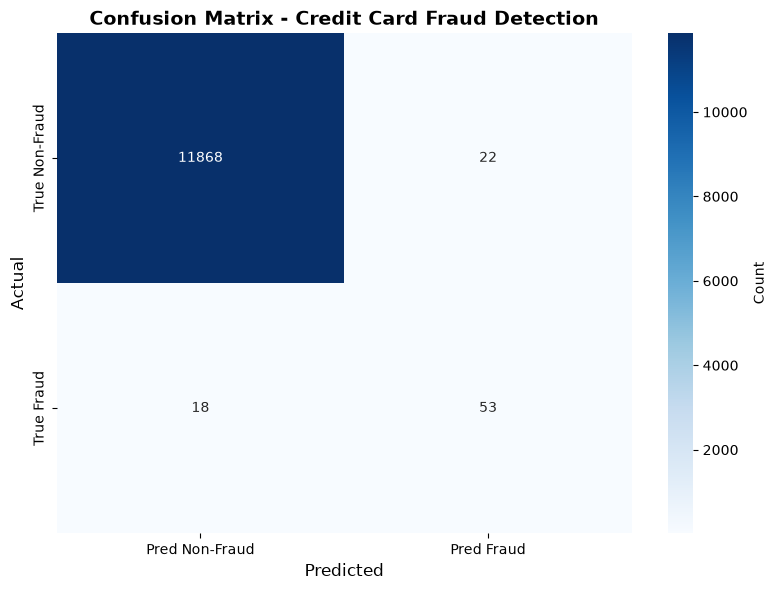

CONFUSION MATRIX BREAKDOWN
True Negatives:  11,868 (correctly identified non-fraud)
False Positives:    22 (non-fraud flagged as fraud)
False Negatives:    18 (fraud missed - CRITICAL)
True Positives:     53 (correctly identified fraud)

Key Insights:
  This represents 25.4% of all actual frauds.
  22 legitimate transactions were flagged as fraud (false alarms).
  This is 0.19% of all legitimate transactions.


In [19]:
# Confusion Matrix
# Visualize model performance showing true/false positives and negatives

import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Predictions on the test set using the full pipeline (on RAW data)
# The pipeline handles preprocessing internally
y_pred = full_pipeline.predict(X_test)

# Create confusion matrix. Tiny smoke datasets may have only one class in y_test.
cm = confusion_matrix(y_test, y_pred, labels=[False, True])

# Visualize confusion matrix
fig, ax = plt.subplots(figsize=(8, 6))
df_cm = pd.DataFrame(cm, 
                     index=['True Non-Fraud', 'True Fraud'],
                     columns=['Pred Non-Fraud', 'Pred Fraud'])

sns.heatmap(df_cm, annot=True, fmt='d', cmap='Blues', ax=ax, cbar_kws={'label': 'Count'})
ax.set_title('Confusion Matrix - Credit Card Fraud Detection', fontsize=14, fontweight='bold')
ax.set_ylabel('Actual', fontsize=12)
ax.set_xlabel('Predicted', fontsize=12)

plt.tight_layout()
cm_fig = fig  # Store for saving later
plt.show()

# Print confusion matrix breakdown
print("=" * 80)
print("CONFUSION MATRIX BREAKDOWN")
print("=" * 80)
print(f"True Negatives:  {cm[0,0]:5,} (correctly identified non-fraud)")
print(f"False Positives: {cm[0,1]:5,} (non-fraud flagged as fraud)")
print(f"False Negatives: {cm[1,0]:5,} (fraud missed - CRITICAL)")
print(f"True Positives:  {cm[1,1]:5,} (correctly identified fraud)")

print("\nKey Insights:")
if cm[1,0] > 0:
    print(f"  WARNING: {cm[1,0]} fraudulent transactions were missed!")
    print(f"  This represents {cm[1,0]/(cm[1,0]+cm[1,1])*100:.1f}% of all actual frauds.")
if cm[0,1] > 0:
    print(f"  {cm[0,1]} legitimate transactions were flagged as fraud (false alarms).")
    print(f"  This is {cm[0,1]/(cm[0,0]+cm[0,1])*100:.2f}% of all legitimate transactions.")

In [20]:
# Classification Metrics
# Comprehensive evaluation with metrics appropriate for imbalanced classification

from sklearn.metrics import (
    classification_report, confusion_matrix, 
    roc_auc_score, precision_recall_curve, auc,
    precision_score, recall_score, f1_score
)

# y_pred was already computed using full_pipeline.predict(X_test) in the confusion matrix cell

# Classification report
print("=" * 80)
print("CLASSIFICATION REPORT")
print("=" * 80)
report_dict = classification_report(
    y_test,
    y_pred,
    labels=[False, True],
    target_names=['Non-Fraud', 'Fraud'],
    output_dict=True,
    zero_division=0,
)
print(classification_report(
    y_test,
    y_pred,
    labels=[False, True],
    target_names=['Non-Fraud', 'Fraud'],
    zero_division=0,
))

# Calculate key metrics
precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)

# Precision-Recall AUC (more important than ROC-AUC for imbalanced data)
precision_curve, recall_curve, _ = precision_recall_curve(y_test, y_pred)
pr_auc = auc(recall_curve, precision_curve)

print("=" * 80)
print("KEY METRICS SUMMARY")
print("=" * 80)
print(f"PR-AUC Score:         {pr_auc:.4f}  <- More important for imbalanced data")
print(f"Precision (Fraud):    {precision:.4f}")
print(f"Recall (Fraud):       {recall:.4f}")
print(f"F1-Score (Fraud):     {f1:.4f}")

# Store metrics for model registry
metrics_dict = {
    'pr_auc': pr_auc,
    'precision': precision,
    'recall': recall,
    'f1_score': f1,
    'accuracy': report_dict['accuracy']
}

print("\nInterpretation:")
print(f"  - Precision: {precision*100:.1f}% of predicted frauds are actually fraudulent")
print(f"  - Recall: {recall*100:.1f}% of actual frauds were detected")
print(f"  - PR-AUC: {pr_auc:.4f} measures precision-recall tradeoff (higher is better)")

CLASSIFICATION REPORT


              precision    recall  f1-score   support

   Non-Fraud       1.00      1.00      1.00     11890
       Fraud       0.71      0.75      0.73        71

    accuracy                           1.00     11961
   macro avg       0.85      0.87      0.86     11961
weighted avg       1.00      1.00      1.00     11961

KEY METRICS SUMMARY
PR-AUC Score:         0.7273  <- More important for imbalanced data
Precision (Fraud):    0.7067
Recall (Fraud):       0.7465
F1-Score (Fraud):     0.7260

Interpretation:
  - Precision: 70.7% of predicted frauds are actually fraudulent
  - Recall: 74.6% of actual frauds were detected
  - PR-AUC: 0.7273 measures precision-recall tradeoff (higher is better)


In [21]:
# Create Model Directory
# Setup directory structure for saving model artifacts
import os

model_dir = "cc_fraud_model"
images_dir = model_dir + "/images"
os.makedirs(images_dir, exist_ok=True)

print("\nModel artifacts will be saved to:", model_dir)


Model artifacts will be saved to: cc_fraud_model


In [22]:
# Save Model Artifacts
# Save the unified Pipeline (preprocessor + model) as a single file

import joblib

print("=" * 80)
print("SAVING MODEL ARTIFACTS")
print("=" * 80)

# Save the unified pipeline (preprocessor + XGBoost in one file)
pipeline_path = model_dir + "/cc_fraud_pipeline.pkl"
joblib.dump(full_pipeline, pipeline_path)
print(f"Unified pipeline saved to: {pipeline_path}")

# Save confusion matrix image
cm_fig.savefig(images_dir + "/confusion_matrix.png", dpi=100, bbox_inches='tight')
print(f"Confusion matrix saved to: {images_dir}/confusion_matrix.png")

# Save feature importance image  
feature_imp_fig.savefig(images_dir + "/feature_importance.png", dpi=100, bbox_inches='tight')
print(f"Feature importance saved to: {images_dir}/feature_importance.png")

print("\n" + "=" * 80)
print("ALL ARTIFACTS SAVED SUCCESSFULLY")
print("=" * 80)
print(f"Total files: 3")
print(f"  - Pipeline: cc_fraud_pipeline.pkl (preprocessor + model combined)")
print(f"  - Visualizations: 2 PNG files")
print("\nFor inference: load cc_fraud_pipeline.pkl -> call pipeline.predict(raw_features)")

SAVING MODEL ARTIFACTS
Unified pipeline saved to: cc_fraud_model/cc_fraud_pipeline.pkl
Confusion matrix saved to: cc_fraud_model/images/confusion_matrix.png
Feature importance saved to: cc_fraud_model/images/feature_importance.png

ALL ARTIFACTS SAVED SUCCESSFULLY
Total files: 3
  - Pipeline: cc_fraud_pipeline.pkl (preprocessor + model combined)
  - Visualizations: 2 PNG files

For inference: load cc_fraud_pipeline.pkl -> call pipeline.predict(raw_features)


In [23]:
# Add the predictor script to the model's directory
predictor_script="ccfraud-predictor.py"
src = Path(f"notebooks/{predictor_script}")
dst_dir = Path(model_dir)
try:
    shutil.copy(src, dst_dir / src.name)
except:
    src = Path(predictor_script)
    shutil.copy(src, dst_dir / src.name)

In [24]:
# Register Model in Hopsworks
# Upload unified pipeline to Hopsworks Model Registry for versioning and deployment

print("=" * 80)
print("REGISTERING MODEL IN HOPSWORKS")
print("=" * 80)

# Format metrics for model registry (must be strings)
metrics_for_registry = {
    'pr_auc': f"{metrics_dict['pr_auc']:.4f}",
    'precision': f"{metrics_dict['precision']:.4f}",
    'recall': f"{metrics_dict['recall']:.4f}",
    'f1_score': f"{metrics_dict['f1_score']:.4f}",
    'accuracy': f"{metrics_dict['accuracy']:.4f}",
    'scale_pos_weight': f"{scale_pos_weight:.2f}",
    'n_train_samples': str(len(y_train)),
    'n_fraud_train': str(n_positive),
    'imbalance_ratio': f"{scale_pos_weight:.2f}"
}

print("Model metadata:")
for key, value in metrics_for_registry.items():
    print(f"  {key:20s}: {value}")

model_name = "cc_fraud_xgboost_model"
# Create model in registry
cc_fraud_model = mr.python.create_model(
    name=model_name,
    metrics=metrics_for_registry,
    feature_view=fv,
    description="Credit Card Fraud Detection - Unified sklearn Pipeline with XGBoost. "
                "Single artifact contains preprocessor (imputation + encoding) and classifier. "
                f"Trained on {len(y_train):,} samples with {n_positive} fraud cases. "
                f"Uses {len(X_train.columns)} raw features, preprocessed internally by pipeline."
)

# Upload model directory to registry
cc_fraud_model.save(model_dir)

print("\n" + "=" * 80)
print("MODEL REGISTRATION COMPLETE")
print("=" * 80)
print(f"Model name: {model_name}")
print(f"Version: {cc_fraud_model.version}")
print(f"Artifact: cc_fraud_pipeline.pkl (unified preprocessor + model)")

REGISTERING MODEL IN HOPSWORKS
Model metadata:
  pr_auc              : 0.7273
  precision           : 0.7067
  recall              : 0.7465
  f1_score            : 0.7260
  accuracy            : 0.9967
  scale_pos_weight    : 272.23
  n_train_samples     : 36067
  n_fraud_train       : 132
  imbalance_ratio     : 272.23


  0%|                                                    | 0/6 [00:00<?, ?it/s]

Creating model folder:   0%|                             | 0/6 [00:00<?, ?it/s]

Creating model folder:  17%|███▌                 | 1/6 [00:00<00:03,  1.54it/s]

Uploading model files:  17%|███▌                 | 1/6 [00:00<00:03,  1.54it/s]

...

Waiting for model registration:  67%|████████    | 4/6 [00:06<00:02,  1.31s/it]

Waiting for model registration:  83%|██████████  | 5/6 [00:11<00:02,  2.75s/it]

Model export complete:  83%|█████████████████▌   | 5/6 [00:11<00:02,  2.75s/it]

Model export complete: 100%|█████████████████████| 6/6 [00:11<00:00,  1.91s/it]

Model created, explore it at https://eu-west.cloud.hopsworks.ai:443/p/36986/models/cc_fraud_xgboost_model/1

MODEL REGISTRATION COMPLETE
Model name: cc_fraud_xgboost_model
Version: 1
Artifact: cc_fraud_pipeline.pkl (unified preprocessor + model)


<span id="papermill-error-cell" style="color:red; font-family:Helvetica Neue, Helvetica, Arial, sans-serif; font-size:2em;">Execution using papermill encountered an exception here and stopped:</span>

In [25]:
ms = proj.get_model_serving()
best_model = mr.get_best_model(name=model_name, metric="f1_score", direction="max")

env_name = "ccfraud-inference-pipeline"

if not env_api.get_environment(env_name):
    env = env_api.create_environment(env_name, base_environment_name="torch-inference-pipeline")
    requirements_path = ds_api.upload(f"{root_dir}/ccfraud/requirements.txt", "Resources", overwrite=True)
    env.install_requirements(requirements_path, await_installation=True)

# If the model I trained is better than the existing model deployment, replace it with this one
if best_model.version == cc_fraud_model.version:
    print(f"This is the best model version at: {best_model.version_path}")
    predictor_path = os.path.join(best_model.version_path, f"Files/{predictor_script}")
    deployment_name = "ccfraud"
    try:
        deployment = ms.get_deployment(deployment_name)
        deployment.delete(force=True)
        print(f"Deleted deployment {deployment_name}")
    except:
        print("Deployment not running")
    deployment = best_model.deploy(name=deployment_name, 
                                   script_file=predictor_path, 
                                   environment=env_name
                                  )
    deployment.start(await_running=600)
    deployment_state = deployment.get_state().describe()
else:
    print("Not deploying this model, as its performance is worse than the existing deployment")

This is the best model version at: /Projects/featurestorebook/Models/cc_fraud_xgboost_model/1
Deployment not running


Deployment created, explore it at https://eu-west.cloud.hopsworks.ai:443/p/36986/deployments/13317
Before making predictions, start the deployment by using `.start()`


  0%|                                                    | 0/5 [00:00<?, ?it/s]

Creating deployment:   0%|                               | 0/5 [00:00<?, ?it/s]

Creating deployment:  40%|█████████▏             | 2/5 [00:05<00:08,  2.87s/it]

...

Deployment is starting:  80%|████████████████    | 4/5 [02:53<00:13, 13.41s/it]

Deployment is starting:  80%|████████████████    | 4/5 [02:58<00:13, 13.41s/it]

Deployment is starting:  80%|████████████████    | 4/5 [03:03<00:13, 13.41s/it]

Deployment is starting:  80%|████████████████    | 4/5 [03:08<00:13, 13.41s/it]

ModelServingException: Deployment has not reached the desired status within the expected awaiting time. Check the current status by using `.get_state()`, explore the server logs using `.get_logs()` or set a higher value for await_running